<div style="background:linear-gradient(135deg,#064e3b 0%,#047857 55%,#34d399 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#a7f3d0;font-weight:700;text-transform:uppercase">Chapter 177 &middot; Capstone 17 &middot; Stratified Sampling</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">A National Customer Study</div>
  <div style="font-size:15px;color:#d1fae5;max-width:820px;line-height:1.6">Sixty thousand customers, a budget for about twelve hundred invitations, and a question that has to be answered to within three points. This project starts before any data exists, and finishes by showing what the naive answer would have got wrong.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportion_confint
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
EM, DK, LT, RD, GR, MUT = "#047857", "#064e3b", "#34d399", "#dc2626", "#16a34a", "#94a3b8"

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-stratified-customer-survey.xlsx"
def load(sheet):
    try:    return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE + fn, sheet_name=sheet)

raw     = load("sample")
frame   = load("frame_summary")
margins = load("population_margins")
truth   = load("truth")
qn      = load("Questionnaire")
plan    = load("SamplingPlan")
REG = ["Northeast","Midwest","South","West"]; AGE = ["18-34","35-54","55+"]
print("invited records:", len(raw))
raw.head()

invited records: 1202


,customer_id,region,age_band,tenure_years,responded,satisfaction,recommend
0,C224393,Midwest,35-54,4.0,1,5.0,1.0
1,C222268,Midwest,55+,3.1,1,6.0,0.0
2,C253620,West,18-34,5.0,1,7.0,1.0
3,C203281,Northeast,35-54,6.4,1,5.0,1.0
4,C243667,SOUTH,35-54,3.2,1,5.0,1.0


## Step D1 &middot; Who exactly is the population?
Before anything else, a sentence that can be checked: **all 60,000 active retail customers on the register at the study date**. Not "our customers", which is vague, and not "people who use the service", which is a different group. The estimate at the end is an estimate of a number that exists for that population and no other.

## Step D2 &middot; The frame, and who it silently excludes
We cannot draw from the population. We draw from a **list**, and the list is customers holding a usable contact record. The gap between the two is coverage error, and it is fixed before a single questionnaire goes out.

In [2]:
cov = frame[["region","population_customers","frame_customers"]].copy()
cov["excluded"] = cov.population_customers - cov.frame_customers
cov["excluded_pct"] = (cov.excluded / cov.population_customers * 100).round(1)
print(cov.to_string(index=False))
N = cov.population_customers.sum(); F = cov.frame_customers.sum()
print(f"\npopulation {N:,}   frame {F:,}   coverage {F/N:.1%}   excluded {N-F:,} customers")

   region  population_customers  frame_customers  excluded  excluded_pct
Northeast                 18000            16694      1306           7.3
  Midwest                 14000            13032       968           6.9
    South                 20000            18951      1049           5.2
     West                  8000             6785      1215          15.2

population 60,000   frame 55,462   coverage 92.4%   excluded 4,538 customers


**The first limitation, written down before collection.** The frame reaches 92.4 percent of customers, and the shortfall is not spread evenly: **15.2 percent of customers in the West are unreachable** against about 5 percent in the South. Younger customers are the ones most often missing a usable contact record.

This matters more than it looks. Those customers have **zero** probability of selection, so no weighting scheme applied inside the sample can bring them back. Whatever we conclude is a conclusion about contactable customers, and the report has to say so.

## Step D3 &middot; How to draw, and how to allocate
Region is the stratum, for two reasons: the business needs an estimate per region, and satisfaction genuinely differs between regions, which is exactly when stratification pays. The interesting decision is how to split the sample across the four strata.

In [3]:
n_invite = 1200
frame["Wh"] = frame.population_customers / N
frame["prop_share"] = (frame.invited_proportional / n_invite * 100).round(1)
frame["ney_share"]  = (frame.invited_neyman / n_invite * 100).round(1)
print(frame[["region","population_customers","pilot_sd_satisfaction",
             "invited_proportional","invited_neyman"]].to_string(index=False))
print("\nproportional: share of sample = share of population")
print("Neyman:       share proportional to (stratum size x stratum SD)")
print("\nThe West is 13.3% of customers but gets",
      f"{frame.loc[frame.region=='West','invited_neyman'].iloc[0]/n_invite:.1%} of the sample,")
print("because its satisfaction is the most variable (SD 1.75 against 1.05 in the South).")

   region  population_customers  pilot_sd_satisfaction  invited_proportional  invited_neyman
Northeast                 18000                   1.25                   360             353
  Midwest                 14000                   1.35                   280             297
    South                 20000                   1.05                   400             330
     West                  8000                   1.75                   160             220

proportional: share of sample = share of population
Neyman:       share proportional to (stratum size x stratum SD)

The West is 13.3% of customers but gets 18.3% of the sample,
because its satisfaction is the most variable (SD 1.75 against 1.05 in the South).


**Why Neyman allocation over proportional.** Proportional allocation gives each region a share of the sample equal to its share of the population, which feels fair and is not optimal. Precision is limited by where the *variation* is: a stratum whose members all answer alike needs few observations to pin down, and a stratum whose members disagree needs more.

Neyman allocation makes each stratum's share proportional to its size **times its standard deviation**. The West is 13 percent of customers and gets 18 percent of the sample, because Western customers disagree with each other more than anyone else. The South is 33 percent of customers and gets 28 percent, because Southern customers are unusually consistent.

The cost of this choice appears later: a design that samples strata at different rates produces **unequal selection probabilities**, and those have to be undone with weights at the analysis stage. Optimal allocation is not free.

## Step D4 &middot; How many, and how precise
The requirement came from the business: the headline proportion must be known to within **three percentage points**. Sample size follows from that, rather than the other way round.

In [4]:
Z, MOE = 1.96, 0.03
n_srs = int(np.ceil(Z**2 * 0.25 / MOE**2))
n_fpc = int(np.ceil(n_srs / (1 + (n_srs - 1) / N)))
print(f"n for +/-{MOE:.0%} at 95% confidence, worst case p = 0.5:   {n_srs}")
print(f"after the finite population correction on N = {N:,}:        {n_fpc}")
print(f"expected response rate about 65%, so invitations needed:   {int(np.ceil(n_fpc/0.65))}")
print(f"invited in practice:                                       {n_invite}\n")
for m in (0.05, 0.04, 0.03, 0.02, 0.01):
    print(f"  margin of error +/-{m:.0%}  ->  n = {int(np.ceil(Z**2*0.25/m**2)):,}")

n for +/-3% at 95% confidence, worst case p = 0.5:   1068
after the finite population correction on N = 60,000:        1050
expected response rate about 65%, so invitations needed:   1616
invited in practice:                                       1200

  margin of error +/-5%  ->  n = 385
  margin of error +/-4%  ->  n = 601
  margin of error +/-3%  ->  n = 1,068
  margin of error +/-2%  ->  n = 2,401
  margin of error +/-1%  ->  n = 9,604


**Two things worth noticing.** The finite population correction barely helps: 1,068 becomes 1,050 even though we are sampling from only 60,000 people. Correction matters when the sample is a large share of the population, and 2 percent is not a large share.

The table at the bottom is the budget conversation in five lines. Going from three points of precision to two costs more than twice the sample, and going to one point costs ten times. **Precision improves with the square root of n**, so each extra decimal place of confidence is bought at a steeply rising price.

## Step D5 &middot; The instrument
Six questions. Two of them are not asked at all: region and age band come from the frame, which means we hold them for **everyone we invited**, not just the people who replied. That single design choice is what makes the whole of the second half of this notebook possible.

In [5]:
for _, r in qn.iterrows():
    print(f"  Q{r['no']}. {r['question']}")
    print(f"      {r['type']}   |   {r['answer_options']}\n")

  Q1. Which region do you live in?
      Nominal (single choice, pre-filled from the frame)   |   Northeast / Midwest / South / West

  Q2. Which age band are you in?
      Nominal (single choice)   |   18-34 / 35-54 / 55+

  Q3. How long have you been a customer?
      Continuous (numeric entry)   |   Years, to one decimal

  Q4. Overall, how satisfied are you with our service?
      Ordinal (7-point Likert)   |   1 = Very dissatisfied ... 7 = Very satisfied

  Q5. Would you recommend us to a friend or colleague?
      Binary (yes/no)   |   Yes / No

  Q6. What one thing would most improve our service? (optional)
      Open text   |   Free response



**Why carrying frame variables matters so much.** Non-response can only be corrected using variables you know for responders *and* non-responders. Ask for age on the questionnaire and you learn it only from people who answered, which is precisely the group you are trying to adjust away from. Take it from the frame and you can compare the two groups directly.

Note also the data types, fixed here and unchangeable later. Satisfaction is a **7-point Likert item**, so it is ordinal and will be reported as a top-two-box share rather than a mean. The recommend question is **binary**, which is why it makes the cleanest headline.

## Step 1 &middot; Clean the returned file

In [6]:
before = len(raw)
df = raw.drop_duplicates(); a_dup = len(df)
df = df.copy()
df["region"] = df.region.str.strip().str.title()
bad = df[df.responded.eq(1) & ~df.satisfaction.between(1,7)]
df.loc[bad.index, ["satisfaction","recommend"]] = np.nan
df.loc[bad.index, "responded"] = 0
print(f"start {before}  ->  dedup {a_dup} (-{before-a_dup})")
print("out-of-range satisfaction codes voided:", bad.satisfaction.tolist())
print("regions after normalizing:", sorted(df.region.unique()))
resp = df[df.responded == 1].copy()
print(f"\ninvited {len(df)}   responded {len(resp)}   response rate {len(resp)/len(df):.1%}")

start 1202  ->  dedup 1200 (-2)
out-of-range satisfaction codes voided: [9.0]
regions after normalizing: ['Midwest', 'Northeast', 'South', 'West']

invited 1200   responded 739   response rate 61.6%


## Step 2 &middot; First look

Nine steps of estimation are coming, all of them about one number. Before any of that, look at what the respondents actually said.

In [7]:
print("SATISFACTION, 1 TO 7, AMONG THE PEOPLE WHO ANSWERED")
print(resp.satisfaction.describe(percentiles=[.25,.5,.75]).round(2).to_string())
print(f"  skewness {resp.satisfaction.skew():+.3f}")
print()
for v in range(1, 8):
    n = int((resp.satisfaction == v).sum())
    print(f"  {v}  {n:4d}  {n/len(resp):6.1%}  {'#'*int(round(n/len(resp)*90))}")

print(f"\nWOULD RECOMMEND: {resp.recommend.mean():.1%} of respondents")
print("\nAND HOW THE TWO ANSWERS LINE UP")
print(f"  {'satisfaction':>13s} {'n':>6s} {'would recommend':>18s}")
for v in range(1, 8):
    g = resp[resp.satisfaction == v]
    if len(g):
        print(f"  {v:>13d} {len(g):>6d} {g.recommend.mean():>17.1%}")

print("\nACHIEVED SAMPLE BY STRATUM")
print(pd.crosstab(resp.region, resp.age_band).reindex(REG)[AGE].to_string())

SATISFACTION, 1 TO 7, AMONG THE PEOPLE WHO ANSWERED
count    739.00
mean       4.94
std        1.38
min        1.00
25%        4.00
50%        5.00
75%        6.00
max        7.00
  skewness -0.525

  1    13    1.8%  ##
  2    25    3.4%  ###
  3    67    9.1%  ########
  4   153   20.7%  ###################
  5   205   27.7%  #########################
  6   184   24.9%  ######################
  7    92   12.4%  ###########

WOULD RECOMMEND: 63.5% of respondents

AND HOW THE TWO ANSWERS LINE UP
   satisfaction      n    would recommend
              1     13             23.1%
              2     25             24.0%
              3     67             23.9%
              4    153             46.4%
              5    205             65.4%
              6    184             83.2%
              7     92             93.5%

ACHIEVED SAMPLE BY STRATUM
age_band   18-34  35-54  55+
region                      
Northeast     40     95  100
Midwest       25     68   89
South         21     86  1

**What this shows.** Satisfaction is a lopsided distribution, not a bell. It leans to the high end with a thin unhappy tail, which is the usual shape for a satisfaction item and a reason to be careful with means.

The second table is the one to keep. Recommending tracks satisfaction, and not smoothly. It sits flat at about a quarter for everyone who scored 1, 2 or 3, then climbs steeply: 46 percent at 4, 65 at 5, 83 at 6 and 94 at 7. Note the floor. Roughly one in four of the least satisfied customers says they would recommend us anyway, which is a useful reminder that these are two different questions.

The stratum table is a reminder that some cells are thin. The West has 19 respondents aged 55 and over, so a regional estimate rests on a few dozen people in places. Step 9 comes back to that.

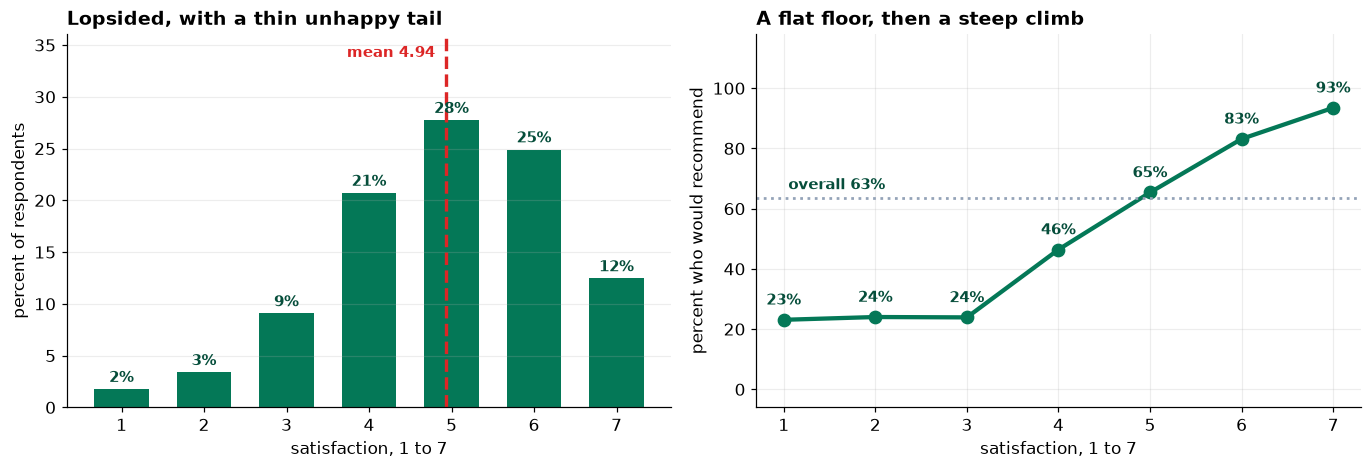

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

ax = axes[0]
vals = list(range(1, 8))
sh = [(resp.satisfaction == v).mean()*100 for v in vals]
ax.bar(vals, sh, color=EM, width=0.66)
for v, s in zip(vals, sh):
    ax.text(v, s + 0.7, f"{s:.0f}%", ha="center", fontsize=10, fontweight="bold", color=DK)
ax.set_ylim(0, max(sh)*1.30)
mu = resp.satisfaction.mean()
ax.axvline(mu, color=RD, lw=2.2, ls="--")
ax.text(mu - 0.14, max(sh)*1.22, f"mean {mu:.2f}", color=RD, fontsize=10,
        fontweight="bold", ha="right")
ax.set_xticks(vals)
ax.set_xlabel("satisfaction, 1 to 7"); ax.set_ylabel("percent of respondents")
ax.set_title("Lopsided, with a thin unhappy tail")
ax.grid(axis="x", alpha=0)

ax = axes[1]
rate = [resp[resp.satisfaction == v].recommend.mean()*100 for v in vals]
ax.plot(vals, rate, color=EM, lw=2.8, marker="o", ms=8)
for v, r_ in zip(vals, rate):
    ax.annotate(f"{r_:.0f}%", (v, r_), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=10, fontweight="bold", color=DK)
ax.axhline(resp.recommend.mean()*100, color=MUT, lw=1.8, ls=":")
ax.text(1.05, resp.recommend.mean()*100 + 3, f"overall {resp.recommend.mean():.0%}",
        color=DK, fontsize=9.5, fontweight="bold")
ax.set_xticks(vals); ax.set_ylim(-6, 118)
ax.set_xlabel("satisfaction, 1 to 7"); ax.set_ylabel("percent who would recommend")
ax.set_title("A flat floor, then a steep climb")
plt.tight_layout(); plt.show()

**Left:** the mass sits at 5 and 6. The mean of 4.94 falls between two categories and is not a score anybody actually gave, which is one reason the headline for this study is a percentage rather than an average. **Right:** nothing separates a 1 from a 3, and everything happens between 4 and 6. Any shift in the composition of respondents across that range moves the headline a long way, and the next step shows that the composition did shift.

## Step 3 &middot; Who answered, and who did not
This is the step the file was designed to make possible. Because every invited customer is in the data with their region and age band, we can describe the non-responders instead of guessing about them.

In [9]:
print("response rate by region")
by_r = df.groupby("region").responded.agg(["size","sum","mean"]).reindex(REG)
by_r.columns = ["invited","responded","rate"]
print(by_r.assign(rate=(by_r["rate"]*100).round(1)).to_string())
print("\nresponse rate by age band")
by_a = df.groupby("age_band").responded.agg(["size","sum","mean"]).reindex(AGE)
by_a.columns = ["invited","responded","rate"]
print(by_a.assign(rate=(by_a["rate"]*100).round(1)).to_string())

print("\nage profile: population vs respondents")
pop_age = margins.groupby("age_band").population_customers.sum().reindex(AGE)
cmp = pd.DataFrame({
    "population_pct": (pop_age/pop_age.sum()*100).round(1),
    "respondent_pct": (resp.age_band.value_counts(normalize=True).reindex(AGE)*100).round(1)})
cmp["gap_pp"] = (cmp.respondent_pct - cmp.population_pct).round(1)
print(cmp.to_string())

response rate by region
           invited  responded  rate
region                             
Northeast      353        235  66.6
Midwest        297        182  61.3
South          330        227  68.8
West           220         95  43.2

response rate by age band
          invited  responded  rate
age_band                          
18-34         335        114  34.0
35-54         472        297  62.9
55+           393        328  83.5

age profile: population vs respondents
          population_pct  respondent_pct  gap_pp
age_band                                        
18-34               29.6            15.4   -14.2
35-54               39.4            40.2     0.8
55+                 31.0            44.4    13.4


**The sample that came back is not the sample we drew.** Two patterns, and the second one is the dangerous one.

**Region:** the West answered at 43 percent against the South's 69. That was expected and it is partly handled by the design, since Neyman allocation had already over-sampled the West.

**Age:** the 18-34 band answered at 39 percent and the 55+ band at 77. The consequence is in the last table. Under-35s are 30 percent of customers and only 19 percent of respondents; the 55+ band is 30 percent of customers and 43 percent of respondents. **The respondent pool is far older than the customer base.** If age has anything to do with the answer, and it does, the naive estimate is already wrong.

## Step 4 &middot; The naive estimate, and its confident interval

In [10]:
r = resp.copy()
n_r = len(r); k = int(r.recommend.sum())
p_unw = k / n_r
lo_u, hi_u = proportion_confint(k, n_r, method="wilson")
se_u = np.sqrt(p_unw*(1-p_unw)/n_r)
print(f"respondents: {k} of {n_r} would recommend")
print(f"unweighted estimate  {p_unw:.4f}  =  {p_unw*100:.2f}%")
print(f"95% CI (Wilson)      [{lo_u*100:.2f}%, {hi_u*100:.2f}%]")
print(f"margin of error      +/- {1.96*se_u*100:.2f} points   <- the +/-3 the plan asked for")

respondents: 469 of 739 would recommend
unweighted estimate  0.6346  =  63.46%
95% CI (Wilson)      [59.93%, 66.86%]
margin of error      +/- 3.47 points   <- the +/-3 the plan asked for


**On its own terms this looks like a clean result.** Just under 64 percent would recommend, the interval is about three points wide either side exactly as the plan required, and nothing in this output looks wrong. A report could be written from these three lines, and frequently is.

## Step 5 &middot; Post-stratification weights
The respondent pool is the wrong shape. Weighting rebuilds the population shape by counting under-represented groups for more than one person each.

In [11]:
cell_pop = margins.set_index(["region","age_band"]).population_customers
cell_n   = r.groupby(["region","age_band"]).size()
w_map = {k: cell_pop[k] / cell_n[k] for k in cell_n.index}
r["weight"] = [w_map[(a,b)] for a,b in zip(r.region, r.age_band)]
r["weight"] = r.weight / r.weight.mean()           # scale to mean 1 for readability

print("weight by cell (population customers each respondent stands for, scaled)")
wt_tab = r.groupby(["region","age_band"]).weight.agg(["size","mean"]).round(2)
wt_tab.columns = ["respondents","weight"]
print(wt_tab.to_string())
print(f"\nweight range: {r.weight.min():.2f} to {r.weight.max():.2f}  "
      f"(ratio {r.weight.max()/r.weight.min():.1f}x)")

weight by cell (population customers each respondent stands for, scaled)
                    respondents  weight
region    age_band                     
Midwest   18-34              25    1.91
          35-54              68    1.03
          55+                89    0.62
Northeast 18-34              40    1.66
          35-54              95    0.93
          55+               100    0.67
South     18-34              21    2.83
          35-54              86    1.08
          55+               120    0.78
West      18-34              28    1.61
          35-54              48    0.84
          55+                19    0.70

weight range: 0.62 to 2.83  (ratio 4.6x)


**Reading the weights.** A young respondent in the West carries a weight above 2: there were few of them relative to how many exist, so each one speaks for more than two average customers. An older Southern respondent carries a weight near 0.6, because that group answered in numbers well above its share.

The spread of the weights is itself a diagnostic. A ratio of roughly four to one between the largest and smallest weight is workable. Ratios of twenty to one would be a signal that the sample was too badly out of shape to rescue, and that the honest move is to collect more data rather than to weight harder.

## Step 6 &middot; The weighted estimate, and what it costs

In [12]:
w = r.weight.values; y = r.recommend.values
p_wt = np.average(y, weights=w)

# Kish effective sample size: unequal weights waste information
n_eff = w.sum()**2 / (w**2).sum()
deff  = n_r / n_eff
se_w  = np.sqrt(np.average((y - p_wt)**2, weights=w) / n_eff)
lo_w, hi_w = p_wt - 1.96*se_w, p_wt + 1.96*se_w

print(f"weighted estimate    {p_wt:.4f}  =  {p_wt*100:.2f}%")
print(f"95% CI               [{lo_w*100:.2f}%, {hi_w*100:.2f}%]")
print(f"margin of error      +/- {1.96*se_w*100:.2f} points\n")
print(f"Kish effective n     {n_eff:.1f} of {n_r} actual respondents")
print(f"design effect        {deff:.2f}   (weighting cost us {n_r-n_eff:.0f} responses' worth of information)")
print(f"\nSE unweighted {se_u:.4f}  ->  SE weighted {se_w:.4f}   ({se_w/se_u-1:+.1%})")

weighted estimate    0.6064  =  60.64%
95% CI               [56.77%, 64.51%]
margin of error      +/- 3.87 points

Kish effective n     612.4 of 739 actual respondents
design effect        1.21   (weighting cost us 127 responses' worth of information)

SE unweighted 0.0177  ->  SE weighted 0.0197   (+11.5%)


**Weighting is not free.** The estimate moved down by nearly three points, and the interval got *wider*, not narrower. That is the correct behavior and it surprises people. Unequal weights waste information: 739 respondents carry the statistical weight of about 612 equally-weighted ones, a design effect of 1.21.

So weighting trades **bias for variance**. It is worth the trade here, and the next step shows why in the only way that settles the argument.

## Step 7 &middot; The reveal
This population is simulated, which means the true answer is knowable. In real work it never is, and that is exactly why this comparison is worth seeing once.

In [13]:
p_true = float(truth.loc[truth.region=="OVERALL","true_recommend_rate"].iloc[0])
print(f"TRUE population recommend rate      {p_true*100:.2f}%\n")
print(f"{'estimate':22s} {'value':>8s}  {'95% CI':>18s}  {'error':>8s}  covers truth?")
print("-"*76)
for lab, est, lo_, hi_ in [("unweighted (naive)", p_unw, lo_u, hi_u),
                           ("post-stratified",    p_wt,  lo_w, hi_w)]:
    ok = "YES" if lo_ <= p_true <= hi_ else "NO"
    print(f"{lab:22s} {est*100:7.2f}%  [{lo_*100:5.2f}%, {hi_*100:5.2f}%]  {(est-p_true)*100:+7.2f}pp  {ok}")
print(f"\nweighting removed {(1-abs(p_wt-p_true)/abs(p_unw-p_true))*100:.0f}% of the naive bias")

TRUE population recommend rate      58.41%

estimate                  value              95% CI     error  covers truth?
----------------------------------------------------------------------------
unweighted (naive)       63.46%  [59.93%, 66.86%]    +5.05pp  NO
post-stratified          60.64%  [56.77%, 64.51%]    +2.23pp  YES

weighting removed 56% of the naive bias


**The naive interval does not contain the truth.** It is not merely off by five points; it is off by five points *while reporting a margin of error of three*. That is the failure mode worth remembering: a badly composed sample does not produce a wide interval and an honest shrug, it produces a **narrow interval in the wrong place**. Precision and accuracy are different things, and the arithmetic only ever reports the first.

The weighted interval does contain the truth, and it is wider. Weighting removed about 56 percent of the bias and paid for it with 21 percent more variance.

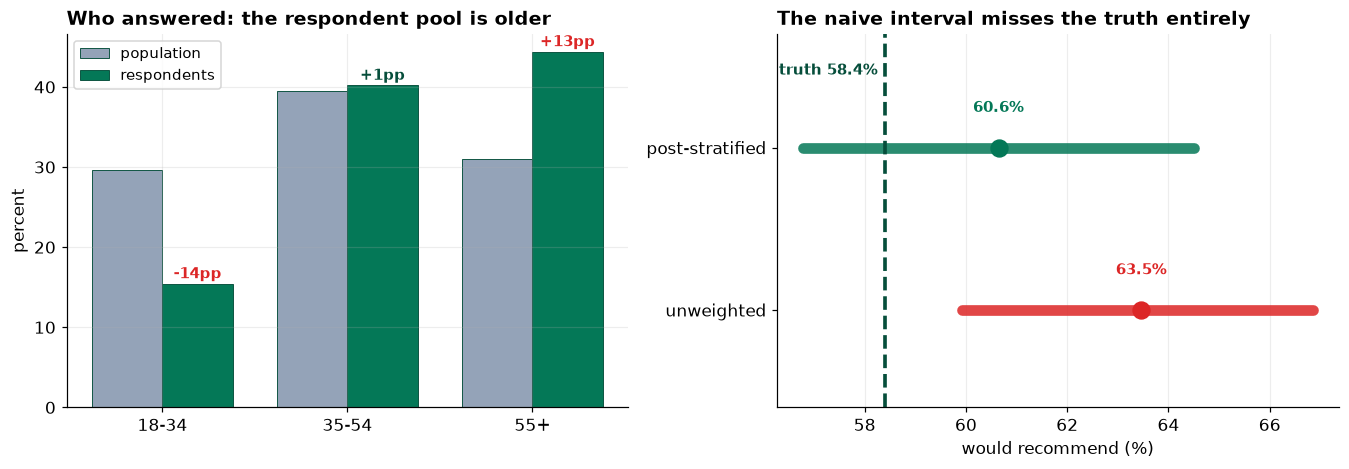

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4))
ax = axes[0]
xs = np.arange(3); w_ = 0.38
pop_pct = (pop_age/pop_age.sum()*100).values
res_pct = (resp.age_band.value_counts(normalize=True).reindex(AGE)*100).values
ax.bar(xs-w_/2, pop_pct, w_, color=MUT, edgecolor=DK, linewidth=0.6, label="population")
ax.bar(xs+w_/2, res_pct, w_, color=EM,  edgecolor=DK, linewidth=0.6, label="respondents")
for i,(a,b) in enumerate(zip(pop_pct,res_pct)):
    ax.text(i+w_/2, b+0.7, f"{b-a:+.0f}pp", ha="center", fontsize=9.5, fontweight="bold",
            color=RD if abs(b-a)>4 else DK)
ax.set_xticks(xs); ax.set_xticklabels(AGE); ax.set_ylabel("percent")
ax.set_title("Who answered: the respondent pool is older"); ax.legend(fontsize=9.5)

ax = axes[1]
for i,(lab,est,lo_,hi_,col) in enumerate([("unweighted", p_unw, lo_u, hi_u, RD),
                                          ("post-stratified", p_wt, lo_w, hi_w, EM)]):
    ax.plot([lo_*100, hi_*100], [i, i], color=col, lw=7, solid_capstyle="round", alpha=0.85)
    ax.plot(est*100, i, "o", color=col, ms=11, zorder=3)
    ax.text(est*100, i+0.22, f"{est*100:.1f}%", ha="center", fontsize=10, fontweight="bold", color=col)
ax.axvline(p_true*100, color=DK, lw=2.4, ls="--")
ax.text(p_true*100-0.15, 1.45, f"truth {p_true*100:.1f}%", ha="right", fontsize=10,
        fontweight="bold", color=DK)
ax.set_yticks([0,1]); ax.set_yticklabels(["unweighted","post-stratified"])
ax.set_ylim(-0.6, 1.7); ax.set_xlabel("would recommend (%)")
ax.set_title("The naive interval misses the truth entirely"); ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()

**The picture of the whole capstone.** On the left, the composition failure: the respondent pool over-represents the 55+ band by 13 points and under-represents the under-35s by 11. On the right, what that does to the answer. The red interval is narrow, confident, and wrong. The green one is wider, less satisfying to report, and contains the truth.

## Step 8 &middot; What the weighting could not fix
Weighting closed most of the gap and not all of it. The residual is worth naming precisely, because it is the part that no analysis can reach.

In [15]:
print(f"remaining bias after weighting: {(p_wt-p_true)*100:+.2f} pp\n")
print("SOURCE 1  coverage: customers who were never in the frame")
exc = cov.excluded.sum()
print(f"   {exc:,} customers ({exc/N:.1%}) had no usable contact record and zero chance of selection.")
print(f"   They are concentrated among younger customers and in the West, and both groups recommend at below-average rates.\n")
print("SOURCE 2  non-response related to the answer itself")
by_sat = resp.groupby("satisfaction").size()
print("   Within every age band, satisfied customers were likelier to reply than unsatisfied ones.")
print("   Satisfaction is not on the frame, so it cannot be used as a weighting margin:")
print("   we only know it for the people who answered, which is the wrong group to learn it from.")
print(f"\n   respondents by satisfaction level:\n{by_sat.to_string()}")

remaining bias after weighting: +2.23 pp

SOURCE 1  coverage: customers who were never in the frame
   4,538 customers (7.6%) had no usable contact record and zero chance of selection.
   They are concentrated among younger customers and in the West, and both groups recommend at below-average rates.

SOURCE 2  non-response related to the answer itself
   Within every age band, satisfied customers were likelier to reply than unsatisfied ones.
   Satisfaction is not on the frame, so it cannot be used as a weighting margin:
   we only know it for the people who answered, which is the wrong group to learn it from.

   respondents by satisfaction level:
satisfaction
1.0     13
2.0     25
3.0     67
4.0    153
5.0    205
6.0    184
7.0     92


**The distinction that matters.** Age and region could be corrected because we knew them for everyone we invited. Satisfaction cannot be corrected, because we know it only for the people who told us, and they are exactly the group whose over-representation is the problem. **A variable you learn from the questionnaire can never be used to adjust for questionnaire non-response.**

Coverage is the same story one step earlier. Customers with no contact record are not under-represented in the respondent pool; they are absent from it, and absent from the frame it was drawn from. The only remedy is a better frame.

## Step 9 &middot; Report the regional estimates properly

In [16]:
rows=[]
for reg in REG:
    sub = r[r.region==reg]
    kk, nn = int(sub.recommend.sum()), len(sub)
    lo_, hi_ = proportion_confint(kk, nn, method="wilson")
    ww = sub.weight.values
    pw = np.average(sub.recommend, weights=ww)
    ne = ww.sum()**2/(ww**2).sum()
    sw = np.sqrt(np.average((sub.recommend-pw)**2, weights=ww)/ne)
    tv = float(truth.loc[truth.region==reg,"true_recommend_rate"].iloc[0])
    rows.append([reg, nn, kk/nn*100, pw*100, (pw-1.96*sw)*100, (pw+1.96*sw)*100, tv*100])
tab = pd.DataFrame(rows, columns=["region","n","unweighted_%","weighted_%","lo_%","hi_%","truth_%"])
print(tab.round(2).to_string(index=False))
print("\ntop-two-box satisfaction (6 or 7), weighted, by region:")
for reg in REG:
    sub = r[r.region==reg]
    t2 = np.average((sub.satisfaction>=6).astype(float), weights=sub.weight.values)
    print(f"   {reg:9s} {t2*100:5.1f}%")

   region   n  unweighted_%  weighted_%  lo_%  hi_%  truth_%
Northeast 235         66.81       63.89 57.35 70.43    58.66
  Midwest 182         58.24       57.24 49.35 65.13    55.54
    South 227         68.72       63.80 56.72 70.87    66.20
     West  95         52.63       51.41 40.72 62.09    43.45

top-two-box satisfaction (6 or 7), weighted, by region:
   Northeast  37.0%
   Midwest    29.7%
   South      48.4%
   West       29.1%


**Regional estimates carry their own margins, and they are wide.** The West rests on 95 respondents, so its interval spans roughly fifteen points. That is the honest consequence of a stratum that both is small and answers reluctantly, and it should stop anyone from ranking the regions confidently on this data.

Satisfaction is reported as a **top-two-box share** rather than a mean, because the scale is ordinal. Weighting applies to it exactly as it did to the recommend question.

## Step 10 &middot; Ethics, bias, and limits
- **The excluded 7.6 percent are a fairness problem, not just a statistical one.** Customers without a contact record are disproportionately young and disproportionately Western. If this survey informs where to invest, the people least able to reach us are also the people least able to influence that decision. That is worth stating in the report rather than in a footnote.
- **Weighting can be pushed until it lies.** Weights of four to one are defensible; weights of twenty to one mean a handful of respondents are carrying the estimate for whole population segments. There is a real temptation to weight aggressively rather than admit a sample failed, and the weight range should always be published alongside the estimate.
- **The response rate is not the headline.** At 62 percent this survey looks respectable, and the naive estimate was still five points wrong. Conversely a 30 percent response rate with no relationship between responding and the answer would have been fine. Publishing the rate without the composition analysis tells the reader nothing.
- **Simulated truth is a teaching device.** The comparison in Step 6 is available here and never in real work. What transfers is not the size of the correction but the habit: describe your non-responders, weight on frame variables, publish the weight range, and name the bias you could not reach.
- **Do not average the Likert item.** Satisfaction is ordinal, so the report gives top-two-box shares. The same discipline as the correlation capstones, applied to a survey that we designed ourselves.

---
**From analysis to report.** The notebook carries the whole chain: the coverage shortfall, the allocation arithmetic, the sample-size derivation, the response-rate breakdown, the weights and their range, the effective sample size, and the comparison against a truth we only have because the population is simulated. The written reports turn it into a recommendation an insight lead can act on and a technical account a fellow statistician can audit. Automate the evidence; author the argument.